In [18]:
# conda env - /data/salomonis2/LabFiles/Frank-Li/scTriangulate/spatial_slide/sctri_spatial_env

In [19]:
import os
import sys
import random
import scanpy as sc
import anndata as ad
import pandas as pd
import anndata as ad
import matplotlib.pyplot as pltx
sys.path.insert(0,'/data/salomonis2/software')
from sctriangulate import ScTriangulate
from sctriangulate.colors import *
from sctriangulate.preprocessing import *
from sctriangulate.spatial import *

In [20]:
# ---------------------------
# Load metadata and expression
# ---------------------------
obs_df = pd.read_csv(
    "/data/salomonis2/LabFiles/Shunya_Asanuma/Spatial/LungChat/Output/Comparison/GSM8509590_GSE250346/Alignment/combined_metadata.csv",
    index_col="Xenium_ID"
)
expr_df = pd.read_csv(
    "/data/salomonis2/LabFiles/Shunya_Asanuma/Spatial/LungChat/Output/Comparison/GSM8509590_GSE250346/Alignment/combined_matrix.csv",
    index_col=0
)

# Match rownames
assert expr_df.shape[0] == obs_df.shape[0], "Mismatch in number of spots"
expr_df.index = obs_df.index
obs_df["Xenium_ID"] = obs_df.index


In [21]:
# ---------------------------
# Create AnnData object
# ---------------------------
adata = ad.AnnData(X=expr_df.values, obs=obs_df)
adata.var_names = expr_df.columns
adata.obs_names = expr_df.index

# Reorder obs columns
new_col_order = ['Xenium_ID', 'Visium_ID'] + [col for col in adata.obs.columns if col not in ['Xenium_ID', 'Visium_ID']]
adata.obs = adata.obs[new_col_order]


In [22]:
adata.obs

,Xenium_ID,Visium_ID,CNiche,TNiche,Final_lineage,Final_CT,Disease_status,Sample_type,Sample_affect,Visium_RCTD_LungMap_ref,...,X_visium_raw,Y_visium_raw,X_xenium_norm,Y_xenium_norm,X_visium_norm,Y_visium_norm,UMAP_1_Visium,UMAP_2_Visium,UMAP_1_Xenium,UMAP_2_Xenium
Xenium_ID,,,,,,,,,,,,,,,,,,,,,
bafcoheg-1,bafcoheg-1,s_008um_00335_00712-1,C3,T2,Immune,CD4+ T-cells,Disease,MF,Less Affected,AF1,...,17066.889712,-24697.411407,0.121135,0.032695,0.116690,0.036102,1.727681,0.832220,0.898606,10.064245
bafegbob-1,bafegbob-1,s_008um_00326_00688-1,C6,T5,Immune,Monocytes/MDMs,Disease,MF,Less Affected,DC,...,17202.255490,-24312.200648,0.135742,0.101559,0.139105,0.098037,1.907830,1.352488,-3.108452,4.804766
bafgdmea-1,bafgdmea-1,s_008um_00285_00662-1,C8,T11,Epithelial,AT2,Disease,MF,Less Affected,AT2,...,17846.571544,-23884.508376,0.244276,0.162502,0.245796,0.166802,-3.191517,5.317749,-4.695938,-3.859683
bafgiagm-1,bafgiagm-1,s_008um_00285_00667-1,C8,T3,Epithelial,AT1,Disease,MF,Less Affected,AM,...,17848.229929,-23964.138714,0.244582,0.158915,0.246070,0.153999,-1.144951,2.275786,-7.044440,-3.284489
bafhcjje-1,bafhcjje-1,s_008um_00283_00663-1,C8,T11,Epithelial,AT2,Disease,MF,Less Affected,AT2,...,17878.754072,-23899.770249,0.251536,0.161256,0.251125,0.164348,-1.911704,5.098765,-5.207698,-4.539240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fniacjoj-1,fniacjoj-1,s_008um_00171_00713-1,C3,T9,Mesenchymal,Alveolar FBs,Disease,MF,Less Affected,AF1,...,19678.984370,-24658.878181,0.550103,0.042540,0.549222,0.042298,-1.643193,-1.369551,5.881905,-2.385230
fniaihjo-1,fniaihjo-1,s_008um_00167_00712-1,C3,T9,Mesenchymal,Alveolar FBs,Disease,MF,Less Affected,Pericyte,...,19742.354853,-24641.623911,0.560342,0.044544,0.559715,0.045072,1.596809,-2.560993,3.624650,-4.178740
fniekdpi-1,fniekdpi-1,s_008um_00163_00701-1,C5,T4,Immune,NK/NKT,Disease,MF,Less Affected,AF1,...,19802.410614,-24465.109497,0.567651,0.073712,0.569660,0.073452,-1.416555,-6.004901,1.061241,10.600194


In [23]:
adata

AnnData object with n_obs × n_vars = 7068 × 4826
    obs: 'Xenium_ID', 'Visium_ID', 'CNiche', 'TNiche', 'Final_lineage', 'Final_CT', 'Disease_status', 'Sample_type', 'Sample_affect', 'Visium_RCTD_LungMap_ref', 'Visium_RCTD_GSE250346_based', 'Xenium_RCTD_LungMap_ref', 'X_xenium_raw', 'Y_xenium_raw', 'X_visium_raw', 'Y_visium_raw', 'X_xenium_norm', 'Y_xenium_norm', 'X_visium_norm', 'Y_visium_norm', 'UMAP_1_Visium', 'UMAP_2_Visium', 'UMAP_1_Xenium', 'UMAP_2_Xenium'

In [24]:
# ---------------------------
# Add spatial coordinates
# ---------------------------
# Required by Squidpy/scTriangulate
# Assign spatial coordinates to expected Scanpy slots
adata.obsm["spatial"] = adata.obs[["X_xenium_norm", "Y_xenium_norm"]].to_numpy()
adata.obsm["X_umap"] = adata.obsm["spatial"]


In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(
    adata.obs["X_xenium_norm"],
    adata.obs["Y_xenium_norm"],  
    s=1, c="gray"
)
plt.xlabel("X_xenium_norm")
plt.ylabel("Y_xenium_norm")
plt.title("Xenium Normalized Spatial Coordinates (Unflipped)")
plt.axis("equal")
plt.show()


In [2]:
# ---------------------------
# Run scTriangulate
# ---------------------------
sctri = ScTriangulate(
    adata=adata,
    dir="/data/salomonis2/LabFiles/Shunya_Asanuma/Spatial/LungChat/Output/Comparison/GSM8509590_GSE250346/scTriangulate/GSM8509590_GSE250346/output_xenium_visium_V14",
    query=[
        "Final_CT",
        "Visium_RCTD_LungMap_ref",
        "Visium_RCTD_GSE250346_based",
        "Xenium_RCTD_LungMap_ref",
        "CNiche",
        "TNiche"
    ]
)

In [3]:
sctri.lazy_run(
    scale_sccaf=False,
    viewer_heterogeneity=True,
    viewer_heterogeneity_keys=["Final_CT"],
    viewer_cluster=True,
    viewer_cluster_keys=["Final_CT"]
)


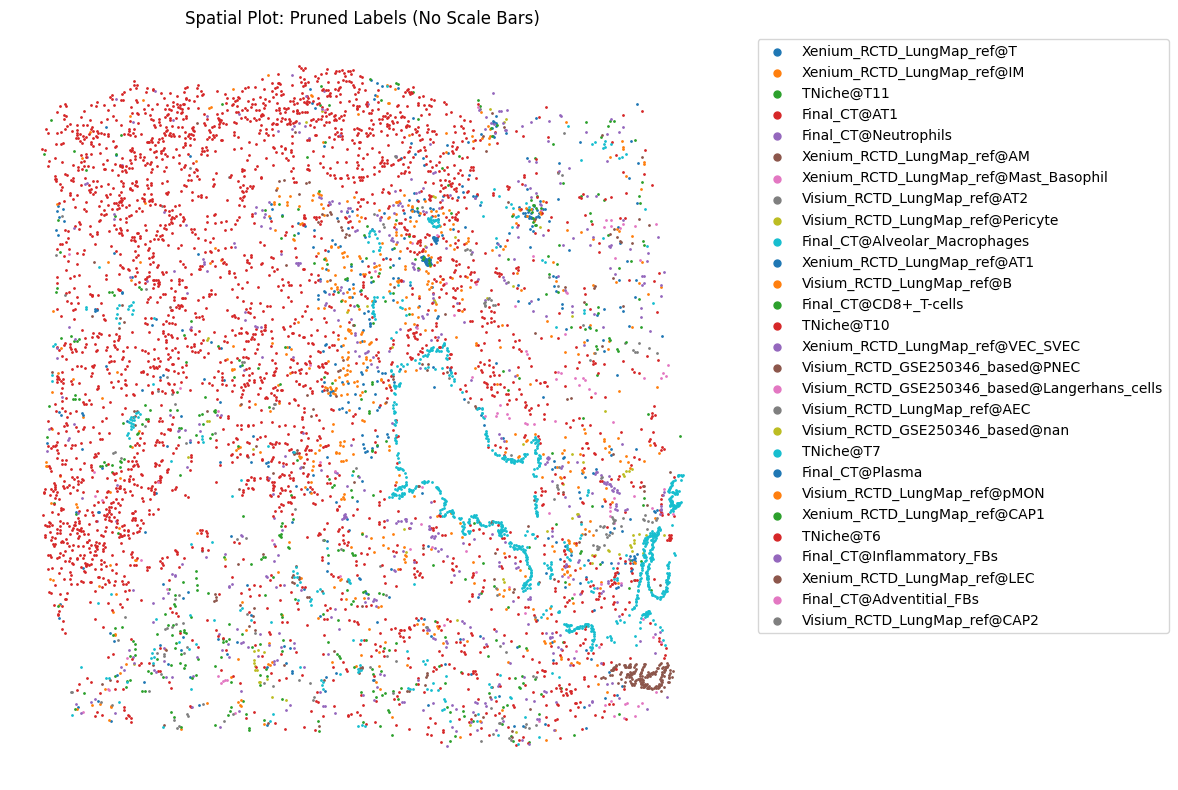

In [34]:
import matplotlib.pyplot as plt

# Copy and filter to range [0, 1]
df = adata.obs.copy()
df["x"] = df["X_xenium_norm"]
df["y"] = df["Y_xenium_norm"]

# Plot without scale bars
plt.figure(figsize=(12, 8))
for ct in df["pruned"].unique():
    sub = df[df["pruned"] == ct]
    plt.scatter(sub["x"], sub["y"], s=1, label=ct)

plt.axis("off")  
plt.title("Spatial Plot: Pruned Labels (No Scale Bars)")
plt.legend(markerscale=5, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [28]:
pruned_counts = adata.obs['pruned'].value_counts().sort_values()

# Show the result
print(pruned_counts)

Visium_RCTD_GSE250346_based@nan                    6
Visium_RCTD_LungMap_ref@pMON                       8
Visium_RCTD_LungMap_ref@CAP2                      13
Final_CT@Plasma                                   18
Xenium_RCTD_LungMap_ref@CAP1                      19
Visium_RCTD_GSE250346_based@Langerhans_cells      19
Xenium_RCTD_LungMap_ref@Mast_Basophil             46
Xenium_RCTD_LungMap_ref@LEC                       46
Final_CT@Adventitial_FBs                          52
Visium_RCTD_LungMap_ref@AEC                       54
Final_CT@Neutrophils                              69
Visium_RCTD_LungMap_ref@Pericyte                  70
Final_CT@AT1                                      76
Xenium_RCTD_LungMap_ref@AT1                       93
Xenium_RCTD_LungMap_ref@AM                       100
Visium_RCTD_LungMap_ref@AT2                      104
Final_CT@Inflammatory_FBs                        107
Visium_RCTD_LungMap_ref@B                        161
Final_CT@CD8+_T-cells                         